In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import rasterio
from rasterio.mask import mask
import os
import warnings
warnings.filterwarnings('ignore')

# Machine learning imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# SHAP for interpretability
import shap

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [19]:
! pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126 tqdm

Looking in indexes: https://download.pytorch.org/whl/cu126
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 9.5 MB/s eta 0:04:35
   ---------------------------------------- 0.0/2.6 GB 15.1 MB/s eta 0:02:52
   ---------------------------------------- 0.0/2.6 GB 15.6 MB/s eta 0:02:46
   ---------------------------------------- 0.0/2.6 GB 12.2 MB/s eta 0:03:32
   ---------------------------------------- 0.0/2.6 GB 12.2 MB/s eta 0:03:33
   ---------------------------------------- 0.0/2.6 GB 13.0 MB/s eta 0:03:19
   ---------------------------------------- 0.0/2.6 GB 13.2 MB/s eta 0:03:15
   ---------------------------------------- 0.0/2.6 GB 14.9 MB/s eta 0:02:53
   ---------------------------------------- 0.0/2.6 GB 14.0 MB/s eta 0:03:05
   ---------------------------------------- 0.0/2.6 GB 13.1 MB/s eta 0:03:18
   ---------------------------------------- 0.0/2.6 GB 13.2 MB/s eta 0:03:15
   -----------------------


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
! pip uninstall torch

^C


In [3]:
# Load the data
print("Loading data...")
df = pd.read_csv('full_test_30.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Display first few rows
df.head()

Loading data...
Dataset shape: (109746, 78)

Columns: ['Unnamed: 0', 'forestry', 'height', 'stock_per_ha', 'geometry', 'B02_min', 'B02_max', 'B02_mean', 'B02_std', 'B03_min', 'B03_max', 'B03_mean', 'B03_std', 'B04_min', 'B04_max', 'B04_mean', 'B04_std', 'B05_min', 'B05_max', 'B05_mean', 'B05_std', 'B06_min', 'B06_max', 'B06_mean', 'B06_std', 'B07_min', 'B07_max', 'B07_mean', 'B07_std', 'B08_min', 'B08_max', 'B08_mean', 'B08_std', 'B8A_min', 'B8A_max', 'B8A_mean', 'B8A_std', 'B11_min', 'B11_max', 'B11_mean', 'B11_std', 'B12_min', 'B12_max', 'B12_mean', 'B12_std', 'ndvi_min', 'ndvi_max', 'ndvi_mean', 'ndvi_std', 'evi_min', 'evi_max', 'evi_mean', 'evi_std', 'gndvi_min', 'gndvi_max', 'gndvi_mean', 'gndvi_std', 'elevation_min', 'elevation_max', 'elevation_mean', 'elevation_std', 'slope_min', 'slope_max', 'slope_mean', 'slope_std', 'aspect_min', 'aspect_max', 'aspect_mean', 'aspect_std', 'hillshade_min', 'hillshade_max', 'hillshade_mean', 'hillshade_std', 'prevailing_species', 'age', 'basal_

,Unnamed: 0,forestry,height,stock_per_ha,geometry,B02_min,B02_max,B02_mean,B02_std,B03_min,...,aspect_std,hillshade_min,hillshade_max,hillshade_mean,hillshade_std,prevailing_species,age,basal_area,carbon_content,date
0,5,Корсаковское,14.0,80,POLYGON ((15910577.720900225 5966096.994759497...,205.0,351.0,261.286604,31.532490,421.0,...,5.550738,163.0,173.0,168.838006,3.190512,2,0,5.714286,23.50000,2019-07-17.tif
1,6,Корсаковское,14.0,60,POLYGON ((15905572.235219263 5966845.150531136...,216.0,383.0,313.311688,33.016922,408.0,...,66.175334,179.0,186.0,182.519481,2.059885,2,0,4.285714,17.62500,2019-07-17.tif
2,9,Корсаковское,14.0,80,POLYGON ((15910577.152855253 5966532.827885686...,263.0,599.0,369.000000,64.667249,512.0,...,15.467266,185.0,207.0,197.801296,6.183955,2,0,5.714286,23.50000,2019-07-17.tif
3,10,Корсаковское,14.0,45,POLYGON ((15911554.803384108 5966417.297229561...,306.0,1134.0,425.203046,104.560571,635.0,...,73.630307,162.0,182.0,173.497462,5.943579,2,0,3.214286,13.21875,2019-07-17.tif
4,36,Корсаковское,15.0,60,POLYGON ((15915624.974079043 5965526.033530008...,188.0,503.0,330.289403,66.776651,386.0,...,133.756580,155.0,207.0,184.305432,13.759356,2,0,4.000000,17.62500,2019-07-17.tif


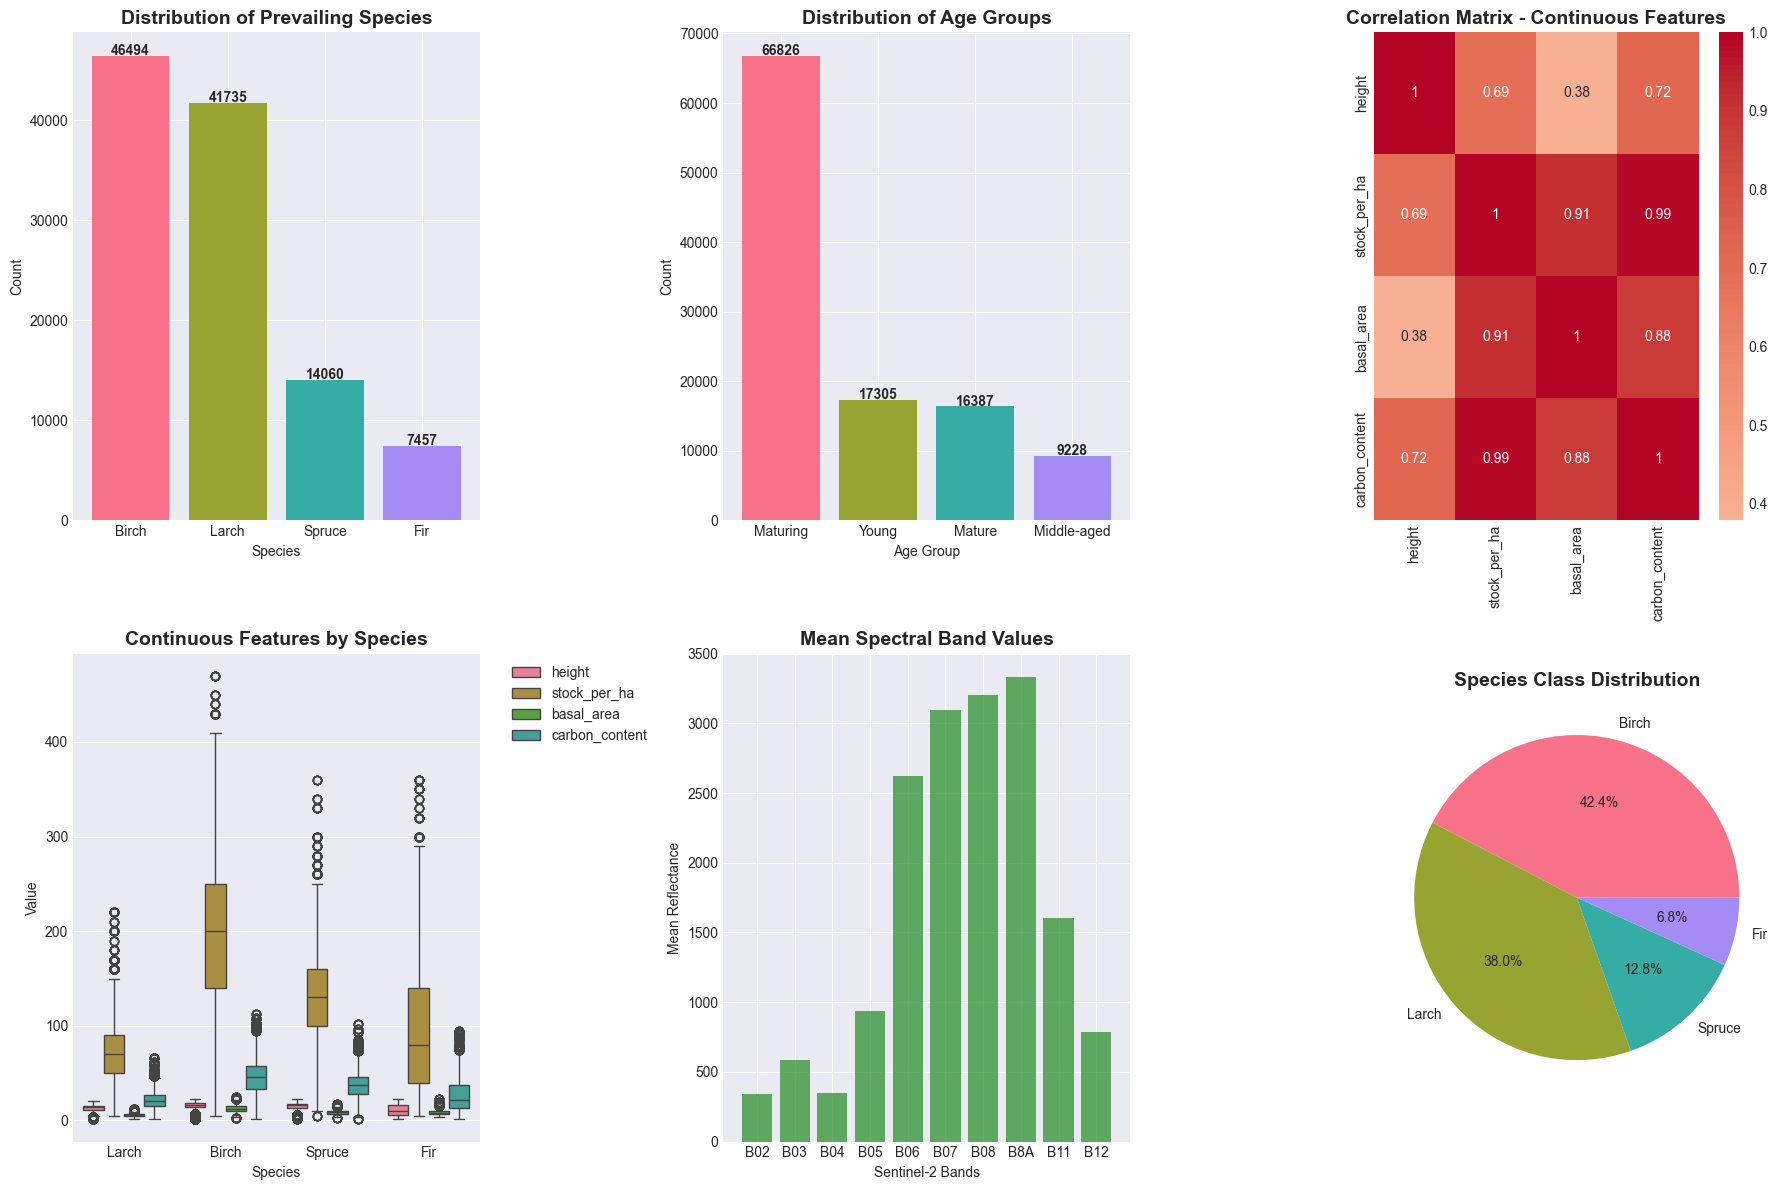

In [4]:
# 1. DATA VISUALIZATION

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1.1 Distribution of species classes
species_names = {0: 'Fir', 1: 'Birch', 2: 'Larch', 3: 'Spruce'}
df['species_name'] = df['prevailing_species'].map(species_names)

ax1 = axes[0, 0]
species_counts = df['species_name'].value_counts()
bars = ax1.bar(species_counts.index, species_counts.values, color=sns.color_palette("husl", 4))
ax1.set_title('Distribution of Prevailing Species', fontsize=14, fontweight='bold')
ax1.set_xlabel('Species')
ax1.set_ylabel('Count')
for bar, count in zip(bars, species_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{count}', ha='center', fontweight='bold')

# 1.2 Distribution of age groups
age_names = {0: 'Young', 1: 'Middle-aged', 2: 'Maturing', 3: 'Mature'}
df['age_name'] = df['age'].map(age_names)

ax2 = axes[0, 1]
age_counts = df['age_name'].value_counts()
bars = ax2.bar(age_counts.index, age_counts.values, color=sns.color_palette("husl", 4))
ax2.set_title('Distribution of Age Groups', fontsize=14, fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Count')
for bar, count in zip(bars, age_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{count}', ha='center', fontweight='bold')

# 1.3 Correlation matrix of continuous features
ax3 = axes[0, 2]
continuous_features = ['height', 'stock_per_ha', 'basal_area', 'carbon_content']
corr_matrix = df[continuous_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix - Continuous Features', fontsize=14, fontweight='bold')

# 1.4 Box plots of continuous features by species
ax4 = axes[1, 0]
df_melted = df.melt(id_vars=['species_name'], value_vars=['height', 'stock_per_ha', 'basal_area', 'carbon_content'])
sns.boxplot(data=df_melted, x='species_name', y='value', hue='variable', ax=ax4)
ax4.set_title('Continuous Features by Species', fontsize=14, fontweight='bold')
ax4.set_xlabel('Species')
ax4.set_ylabel('Value')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 1.5 Spectral bands statistics
ax5 = axes[1, 1]
band_columns = [col for col in df.columns if any(band in col for band in ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12'])]
band_means = df[band_columns].mean()
band_names = [col.replace('_mean', '') for col in band_means.index if '_mean' in col]
band_values = [df[f'{band}_mean'].mean() for band in ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']]
ax5.bar(band_names, band_values, color='forestgreen', alpha=0.7)
ax5.set_title('Mean Spectral Band Values', fontsize=14, fontweight='bold')
ax5.set_xlabel('Sentinel-2 Bands')
ax5.set_ylabel('Mean Reflectance')
plt.xticks(rotation=45)

# 1.6 Class imbalance visualization
ax6 = axes[1, 2]
species_percentages = species_counts / len(df) * 100
ax6.pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("husl", 4))
ax6.set_title('Species Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()


Creating map visualizations...


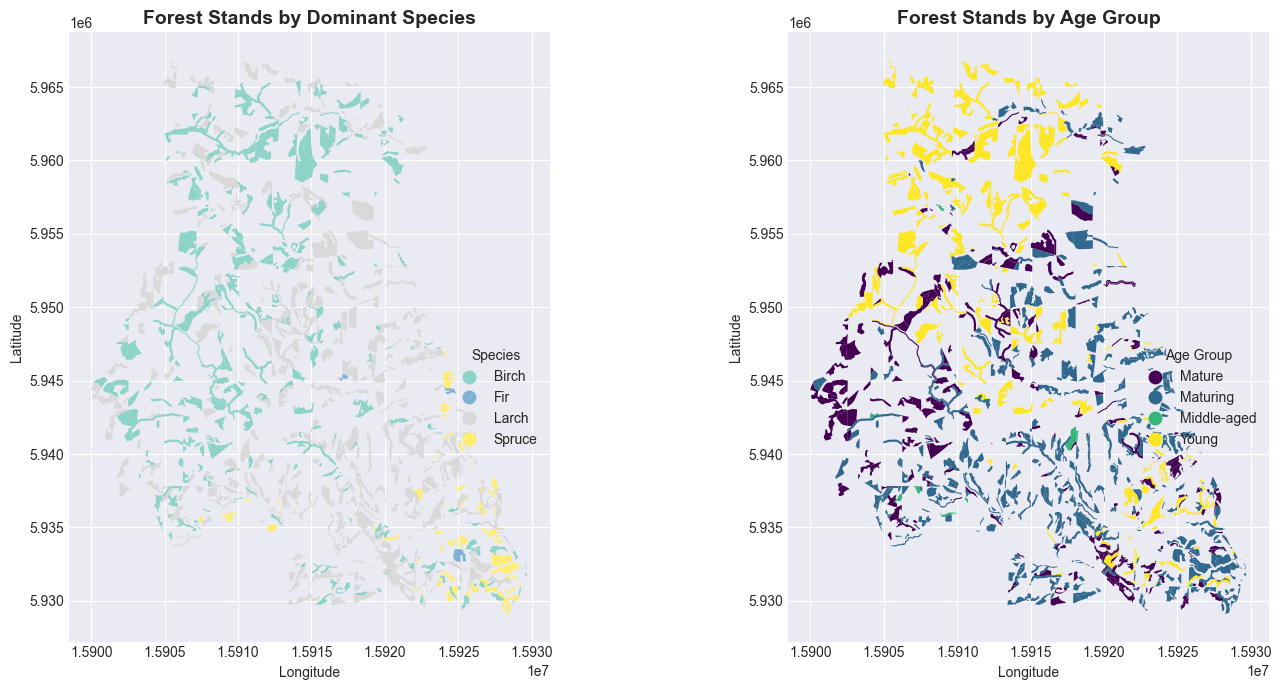

NameError: name 'species_labels' is not defined

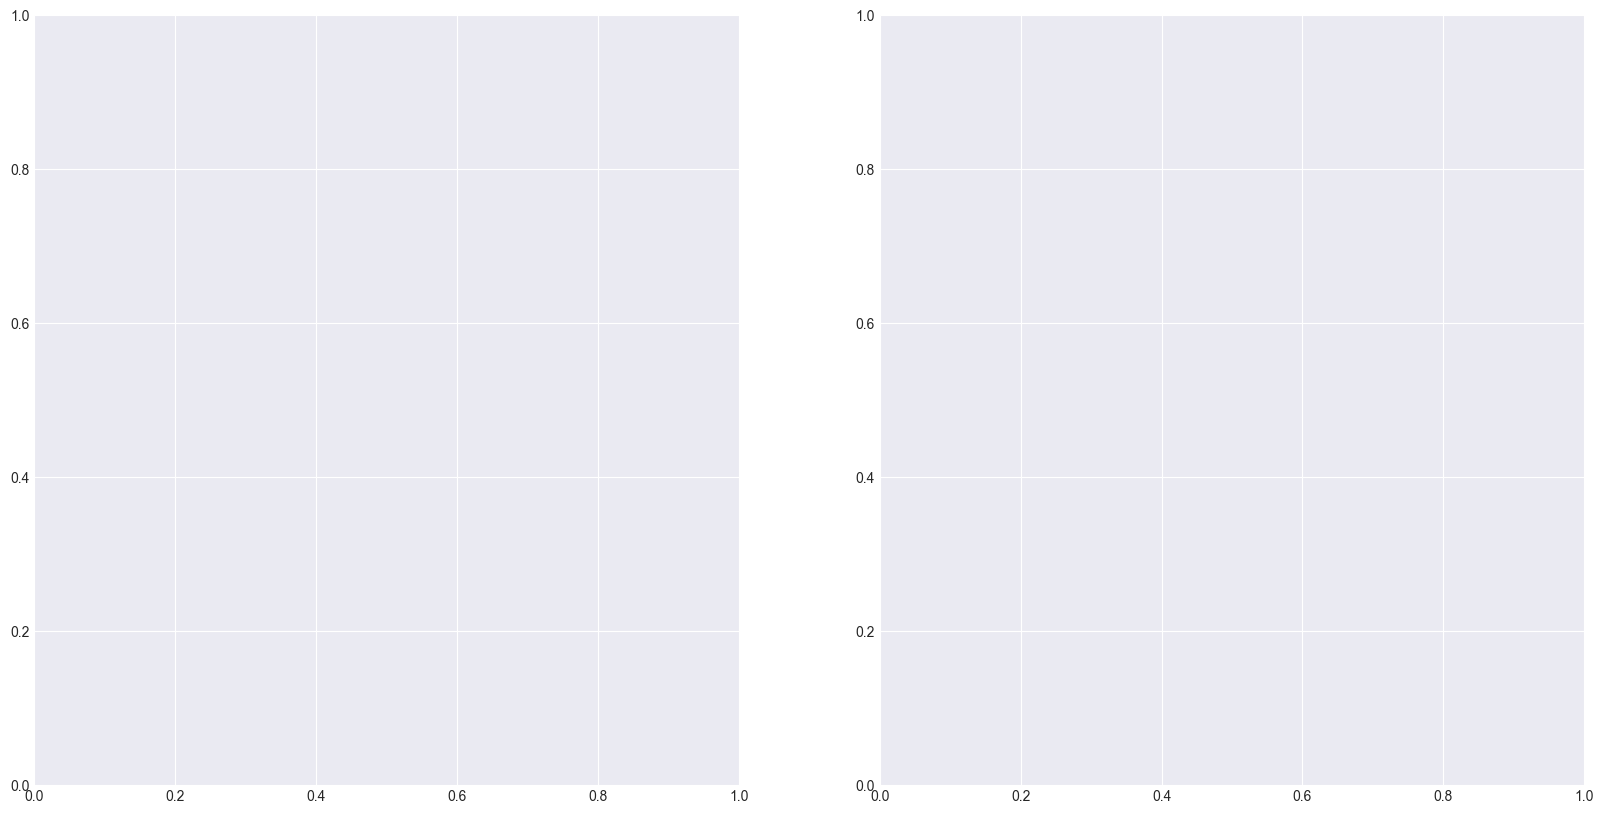

In [ ]:
# Additional visualization - Maps
print("\nCreating map visualizations...")

# Create sample geometries for map visualization
gdf = gpd.GeoDataFrame(df.head(1000), geometry=gpd.GeoSeries.from_wkt(df['geometry'].head(1000)), crs='EPSG:3857')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Map by species
gdf.plot(column='species_name', ax=ax1, legend=True, cmap='Set3', 
         legend_kwds={'bbox_to_anchor': (1, 0.5), 'title': 'Species'})
ax1.set_title('Forest Stands by Dominant Species', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Map by age group
gdf.plot(column='age_name', ax=ax2, legend=True, cmap='viridis',
         legend_kwds={'bbox_to_anchor': (1, 0.5), 'title': 'Age Group'})
ax2.set_title('Forest Stands by Age Group', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('spatial_distribution_maps.png', dpi=300, bbox_inches='tight')
plt.show()




In [6]:
# 2. DATA PREPARATION FOR ML MODELS

def prepare_features(df, feature_type='spectral'):
    """
    Prepare features for machine learning models
    feature_type: 'spectral', 'vegetation_indices', or 'all'
    """
    
    # Spectral bands (means and stds)
    spectral_bands = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']
    
    # Calculate vegetation indices if not present
    if 'ndvi_mean' not in df.columns:
        df['ndvi_mean'] = (df['B08_mean'] - df['B04_mean']) / (df['B08_mean'] + df['B04_mean'] + 1e-10)
        df['ndwi_mean'] = (df['B03_mean'] - df['B08_mean']) / (df['B03_mean'] + df['B08_mean'] + 1e-10)
        df['gndvi_mean'] = (df['B08_mean'] - df['B03_mean']) / (df['B08_mean'] + df['B03_mean'] + 1e-10)
        # SAVI (Soil Adjusted Vegetation Index)
        L = 0.5
        df['savi_mean'] = ((df['B08_mean'] - df['B04_mean']) / (df['B08_mean'] + df['B04_mean'] + L)) * (1 + L)
        # FACI (Forest Area Condition Index) - simplified
        df['faci_mean'] = (df['B08_mean'] - df['B04_mean']) / (df['B08_mean'] + df['B04_mean'] + df['B03_mean'] + 1e-10)
    
    vegetation_indices = ['ndvi_mean', 'ndwi_mean', 'gndvi_mean', 'savi_mean', 'faci_mean']
    topographic_features = ['elevation_mean', 'slope_mean', 'aspect_mean', 'hillshade_mean']
    
    if feature_type == 'spectral':
        # Band means and stds
        features = [f'{band}_mean' for band in spectral_bands] + [f'{band}_std' for band in spectral_bands]
    elif feature_type == 'vegetation_indices':
        features = vegetation_indices
    elif feature_type == 'all':
        features = [f'{band}_mean' for band in spectral_bands] + [f'{band}_std' for band in spectral_bands] + \
                   vegetation_indices + topographic_features
    else:
        raise ValueError("feature_type must be 'spectral', 'vegetation_indices', or 'all'")
    
    # Ensure all features exist
    available_features = [f for f in features if f in df.columns]
    missing = set(features) - set(available_features)
    if missing:
        print(f"Warning: Missing features: {missing}")
    
    return df[available_features].fillna(0)

# Prepare features for different configurations
print("Preparing features...")
X_spectral = prepare_features(df, 'spectral')
X_vegetation = prepare_features(df, 'vegetation_indices')
X_all = prepare_features(df, 'all')

# Target variables
y_species = df['prevailing_species']
y_age = df['age']

print(f"\nSpectral features shape: {X_spectral.shape}")
print(f"Vegetation indices shape: {X_vegetation.shape}")
print(f"All features shape: {X_all.shape}")

Preparing features...

Spectral features shape: (109746, 20)
Vegetation indices shape: (109746, 2)
All features shape: (109746, 26)


In [9]:
# 3. BASELINE MODELS - Random Forest for Species Classification

def evaluate_model(X, y, model, model_name, target_name):
    """Evaluate model performance with cross-validation"""
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Scale features for models that need it
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    if model_name == 'RandomForest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n{'='*50}")
    print(f"{target_name} Classification - {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=species_names.values()))
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"\nCross-validation scores: {cv_scores}")
    print(f"CV mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    return model, X_train, X_test, y_train, y_test, y_pred, y_proba

# Random Forest for species
print("\n" + "="*60)
print("BASELINE MODELS - SPECIES CLASSIFICATION")
print("="*60)

rf_species = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model, X_train, X_test, y_train, y_test, y_pred, y_proba = evaluate_model(
    X_all, y_species, rf_species, 'RandomForest', 'Species'
)

# Random Forest for age
print("\n" + "="*60)
print("BASELINE MODELS - AGE CLASSIFICATION")
print("="*60)

rf_age = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_age_model, X_train_age, X_test_age, y_train_age, y_test_age, y_pred_age, y_proba_age = evaluate_model(
    X_all, y_age, rf_age, 'RandomForest', 'Age'
)


BASELINE MODELS - SPECIES CLASSIFICATION

Species Classification - RandomForest
Accuracy: 0.5720
F1-Score (weighted): 0.5279

Classification Report:
              precision    recall  f1-score   support

         Fir       0.88      0.05      0.10      1492
       Birch       0.54      0.77      0.63      9299
       Larch       0.61      0.61      0.61      8347
      Spruce       0.75      0.09      0.16      2812

    accuracy                           0.57     21950
   macro avg       0.70      0.38      0.38     21950
weighted avg       0.62      0.57      0.53     21950


Cross-validation scores: [0.56361048 0.56005467 0.56267441 0.56369953 0.56107979]
CV mean: 0.5622 (+/- 0.0029)

BASELINE MODELS - AGE CLASSIFICATION

Age Classification - RandomForest
Accuracy: 0.6406
F1-Score (weighted): 0.5412

Classification Report:
              precision    recall  f1-score   support

         Fir       0.72      0.15      0.25      3461
       Birch       0.82      0.05      0.09      184


Testing Spectral Bands features for Species
Accuracy: 0.5271
F1-Score: 0.4758

Testing Vegetation Indices features for Species
Accuracy: 0.4080
F1-Score: 0.3856

Testing All Features features for Species
Accuracy: 0.5720
F1-Score: 0.5279

Testing Spectral Bands features for Age
Accuracy: 0.6131
F1-Score: 0.4926

Testing Vegetation Indices features for Age
Accuracy: 0.5400
F1-Score: 0.4723

Testing All Features features for Age
Accuracy: 0.6406
F1-Score: 0.5412


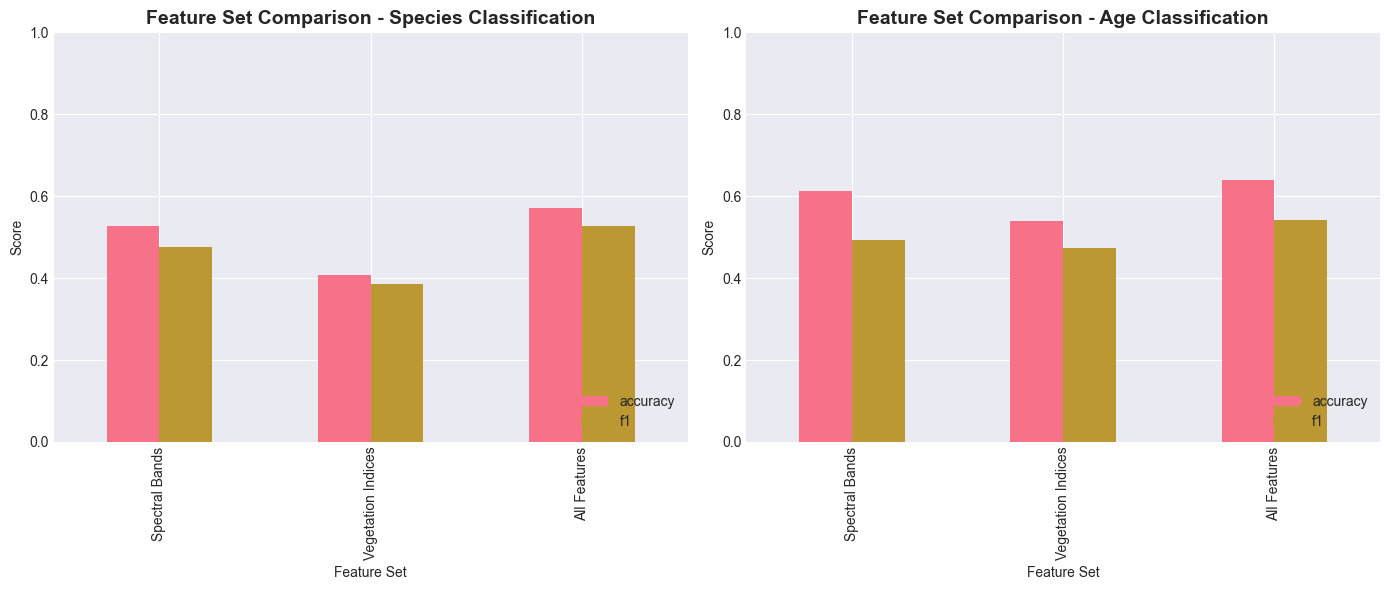

In [10]:
# 4. COMPARE DIFFERENT FEATURE SETS

def compare_feature_sets(X_dict, y, model_class, target_name):
    """Compare model performance across different feature sets"""
    
    results = {}
    
    for feature_name, X in X_dict.items():
        print(f"\n{'='*50}")
        print(f"Testing {feature_name} features for {target_name}")
        print(f"{'='*50}")
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        model = model_class(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[feature_name] = {'accuracy': accuracy, 'f1': f1}
        
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {f1:.4f}")
    
    return results

# Dictionary of feature sets
X_dict = {
    'Spectral Bands': X_spectral,
    'Vegetation Indices': X_vegetation,
    'All Features': X_all
}

# Compare for species
species_results = compare_feature_sets(X_dict, y_species, RandomForestClassifier, 'Species')

# Compare for age
age_results = compare_feature_sets(X_dict, y_age, RandomForestClassifier, 'Age')

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Species results
species_df = pd.DataFrame(species_results).T
species_df.plot(kind='bar', ax=ax1)
ax1.set_title('Feature Set Comparison - Species Classification', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xlabel('Feature Set')
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1)

# Age results
age_df = pd.DataFrame(age_results).T
age_df.plot(kind='bar', ax=ax2)
ax2.set_title('Feature Set Comparison - Age Classification', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xlabel('Feature Set')
ax2.legend(loc='lower right')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('feature_set_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# 5. CNN 1D MODEL

class SimpleCNN1D(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleCNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)
        
        # Calculate flattened size
        self.flattened_size = 128 * (input_dim // 8)
        
        self.fc1 = nn.Linear(self.flattened_size, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_cnn_model(X, y, num_classes, epochs=50, batch_size=32):
    """Train a 1D CNN model"""
    
    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.LongTensor(y_train.values)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_test_tensor = torch.LongTensor(y_test.values)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleCNN1D(X.shape[1], num_classes).to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    train_losses = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs.data, 1)
        predicted = predicted.cpu().numpy()
        
    accuracy = accuracy_score(y_test, predicted)
    f1 = f1_score(y_test, predicted, average='weighted')
    
    print(f"\nCNN Model Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, predicted))
    
    return model, accuracy, f1, train_losses

# Train CNN for species
print("\n" + "="*60)
print("CNN 1D MODEL - SPECIES CLASSIFICATION")
print("="*60)

cnn_species, cnn_acc, cnn_f1, cnn_losses = train_cnn_model(
    X_all, y_species, num_classes=4, epochs=50
)

# Train CNN for age
print("\n" + "="*60)
print("CNN 1D MODEL - AGE CLASSIFICATION")
print("="*60)

cnn_age, cnn_acc_age, cnn_f1_age, cnn_losses_age = train_cnn_model(
    X_all, y_age, num_classes=4, epochs=50
)

# Plot training loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(cnn_losses)
ax1.set_title('CNN Training Loss - Species', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(cnn_losses_age)
ax2.set_title('CNN Training Loss - Age', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.savefig('cnn_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()


CNN 1D MODEL - SPECIES CLASSIFICATION
Epoch [10/50], Loss: 1.0408
Epoch [20/50], Loss: 0.9763
Epoch [30/50], Loss: 0.9259
Epoch [40/50], Loss: 0.8828
Epoch [50/50], Loss: 0.8514

CNN Model Results:
Accuracy: 0.5485
F1-Score: 0.5165

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.06      0.10      1492
           1       0.53      0.72      0.61      9299
           2       0.60      0.58      0.59      8347
           3       0.39      0.14      0.20      2812

    accuracy                           0.55     21950
   macro avg       0.49      0.37      0.38     21950
weighted avg       0.53      0.55      0.52     21950


CNN 1D MODEL - AGE CLASSIFICATION


KeyboardInterrupt: 

In [13]:
# 5. CNN 1D MODEL WITH BATCH NORMALIZATION AND ADAPTIVE ARCHITECTURE

class SimpleCNN1D(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleCNN1D, self).__init__()
        
        # Define activation function first
        self.relu = nn.ReLU()
        
        # Convolutional layers with batch normalization
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)
        
        # Adaptive calculation of flattened size (works with any input dimension)
        self.flattened_size = self._calculate_flattened_size(input_dim)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
    def _calculate_flattened_size(self, input_dim):
        """Dynamically calculate the flattened size after convolutions and pooling"""
        # Create a dummy tensor to pass through conv layers
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_dim)
            
            # Pass through first conv block
            x = self.conv1(dummy_input)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Second conv block
            x = self.conv2(x)
            x = self.bn2(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Third conv block
            x = self.conv3(x)
            x = self.bn3(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Calculate flattened size
            return x.view(1, -1).size(1)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        
        # First conv block with batch normalization
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Second conv block with batch normalization
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Third conv block with batch normalization
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_cnn_model(X, y, num_classes, epochs=50, batch_size=32):
    """Train a 1D CNN model with batch normalization and adaptive architecture"""
    
    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.LongTensor(y_train.values)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_test_tensor = torch.LongTensor(y_test.values)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model (adaptive architecture will handle input dimension)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleCNN1D(X.shape[1], num_classes).to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    train_losses = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs.data, 1)
        predicted = predicted.cpu().numpy()
        
    accuracy = accuracy_score(y_test, predicted)
    f1 = f1_score(y_test, predicted, average='weighted')
    
    print(f"\nCNN Model Results (with Batch Normalization):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, predicted))
    
    return model, accuracy, f1, train_losses

# Train CNN for species
print("\n" + "="*60)
print("CNN 1D MODEL WITH BATCH NORMALIZATION - SPECIES CLASSIFICATION")
print("="*60)

cnn_species, cnn_acc, cnn_f1, cnn_losses = train_cnn_model(
    X_all, y_species, num_classes=4, epochs=50
)

# Train CNN for age
print("\n" + "="*60)
print("CNN 1D MODEL WITH BATCH NORMALIZATION - AGE CLASSIFICATION")
print("="*60)

cnn_age, cnn_acc_age, cnn_f1_age, cnn_losses_age = train_cnn_model(
    X_all, y_age, num_classes=4, epochs=50
)

# Plot training loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(cnn_losses)
ax1.set_title('CNN Training Loss - Species (with BatchNorm)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(cnn_losses_age)
ax2.set_title('CNN Training Loss - Age (with BatchNorm)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.savefig('cnn_training_loss_with_batchnorm.png', dpi=300, bbox_inches='tight')
plt.show()


CNN 1D MODEL WITH BATCH NORMALIZATION - SPECIES CLASSIFICATION
Epoch [10/50], Loss: 1.0563
Epoch [20/50], Loss: 1.0081
Epoch [30/50], Loss: 0.9703
Epoch [40/50], Loss: 0.9388
Epoch [50/50], Loss: 0.9167

CNN Model Results (with Batch Normalization):
Accuracy: 0.5508
F1-Score: 0.5103

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.03      0.06      1492
           1       0.52      0.75      0.61      9299
           2       0.61      0.58      0.59      8347
           3       0.45      0.10      0.16      2812

    accuracy                           0.55     21950
   macro avg       0.52      0.36      0.36     21950
weighted avg       0.54      0.55      0.51     21950


CNN 1D MODEL WITH BATCH NORMALIZATION - AGE CLASSIFICATION


KeyboardInterrupt: 


IMPROVED CNN TRAINING FOR IMBALANCED DATASET
X_all shape: (109746, 26)
y_species shape: (109746,)
Unique classes in y_species: [2 1 3 0]

STRATEGY: WEIGHTED_SAMPLER
Applying SMOTE to balance training data...
Original training size: 87796 -> Balanced size: 148780
Class distribution after SMOTE:
prevailing_species
1    37195
3    37195
0    37195
2    37195
Name: count, dtype: int64
Using device: cuda
Using standard Cross Entropy Loss
Epoch [10/80], Train Loss: 0.7950, Val Loss: 1.2496, LR: 0.001000
Early stopping at epoch 18

CNN Model Results (weighted_sampler):
Accuracy: 0.5074
F1-Score: 0.5171

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.43      0.31      1492
           1       0.59      0.48      0.53      9299
           2       0.60      0.57      0.58      8347
           3       0.34      0.45      0.39      2812

    accuracy                           0.51     21950
   macro avg       0.44      0.48      0.45   

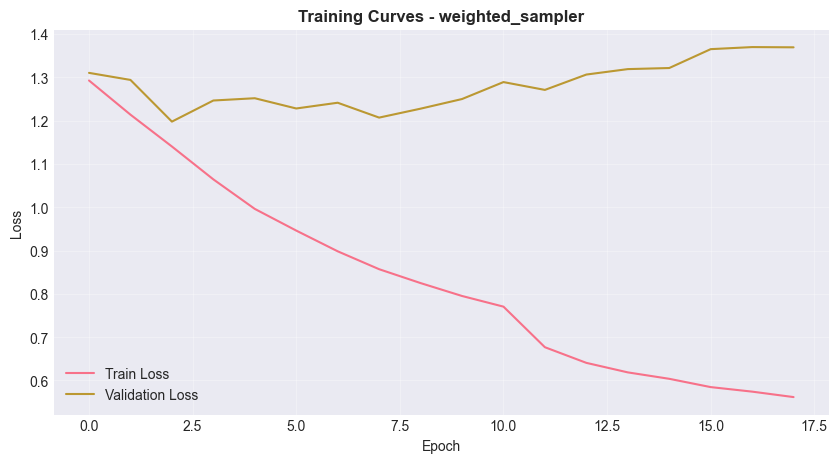


STRATEGY: CLASS_WEIGHTS
Applying SMOTE to balance training data...
Original training size: 87796 -> Balanced size: 148780
Class distribution after SMOTE:
prevailing_species
1    37195
3    37195
0    37195
2    37195
Name: count, dtype: int64
Using device: cuda
Class weights: tensor([3.6796, 0.5901, 0.6574, 1.9514], device='cuda:0')
Epoch [10/80], Train Loss: 0.5815, Val Loss: 1.5006, LR: 0.001000
Early stopping at epoch 18

CNN Model Results (class_weights):
Accuracy: 0.4123
F1-Score: 0.4218

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.52      0.29      1492
           1       0.62      0.26      0.36      9299
           2       0.59      0.48      0.53      8347
           3       0.26      0.67      0.37      2812

    accuracy                           0.41     21950
   macro avg       0.42      0.48      0.39     21950
weighted avg       0.53      0.41      0.42     21950



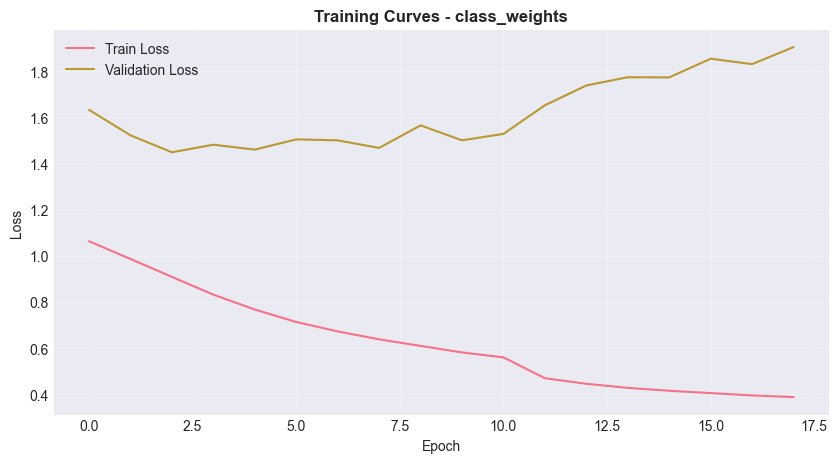


STRATEGY: FOCAL_LOSS
Applying SMOTE to balance training data...
Original training size: 87796 -> Balanced size: 148780
Class distribution after SMOTE:
prevailing_species
1    37195
3    37195
0    37195
2    37195
Name: count, dtype: int64
Using device: cuda
Using Focal Loss
Epoch [10/80], Train Loss: 0.0990, Val Loss: 0.1545, LR: 0.001000
Epoch [20/80], Train Loss: 0.0578, Val Loss: 0.1767, LR: 0.000500
Early stopping at epoch 23

CNN Model Results (focal_loss):
Accuracy: 0.5006
F1-Score: 0.5085

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.44      0.32      1492
           1       0.59      0.44      0.50      9299
           2       0.59      0.59      0.59      8347
           3       0.33      0.46      0.38      2812

    accuracy                           0.50     21950
   macro avg       0.44      0.48      0.45     21950
weighted avg       0.53      0.50      0.51     21950



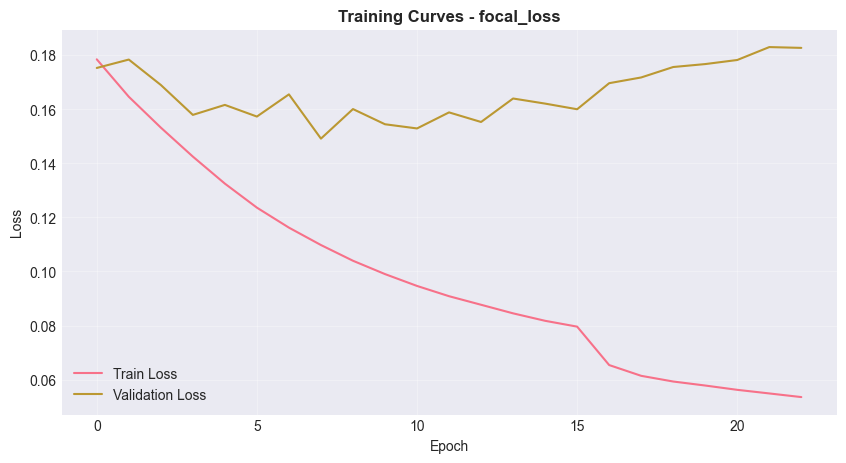


ENSEMBLE MODEL TRAINING

Training with strategy: weighted_sampler
Applying SMOTE to balance training data...
Original training size: 87796 -> Balanced size: 148780
Class distribution after SMOTE:
prevailing_species
1    37195
3    37195
0    37195
2    37195
Name: count, dtype: int64
Using device: cuda
Using standard Cross Entropy Loss
Epoch [10/80], Train Loss: 0.8069, Val Loss: 1.1872, LR: 0.001000
Epoch [20/80], Train Loss: 0.5302, Val Loss: 1.3747, LR: 0.000500
Early stopping at epoch 25

CNN Model Results (weighted_sampler):
Accuracy: 0.5091
F1-Score: 0.5204

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.46      0.32      1492
           1       0.60      0.49      0.54      9299
           2       0.61      0.55      0.58      8347
           3       0.34      0.48      0.40      2812

    accuracy                           0.51     21950
   macro avg       0.45      0.50      0.46     21950
weighted avg       0.55  

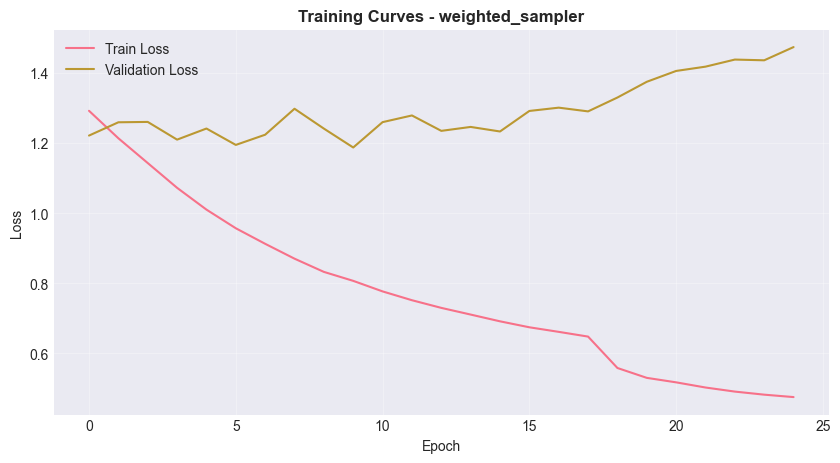


Training with strategy: class_weights
Applying SMOTE to balance training data...
Original training size: 87796 -> Balanced size: 148780
Class distribution after SMOTE:
prevailing_species
1    37195
3    37195
0    37195
2    37195
Name: count, dtype: int64
Using device: cuda
Class weights: tensor([3.6796, 0.5901, 0.6574, 1.9514], device='cuda:0')
Epoch [10/80], Train Loss: 0.5851, Val Loss: 1.4902, LR: 0.001000
Early stopping at epoch 18

CNN Model Results (class_weights):
Accuracy: 0.4240
F1-Score: 0.4348

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.51      0.29      1492
           1       0.61      0.28      0.38      9299
           2       0.60      0.49      0.54      8347
           3       0.26      0.65      0.37      2812

    accuracy                           0.42     21950
   macro avg       0.42      0.48      0.40     21950
weighted avg       0.53      0.42      0.43     21950



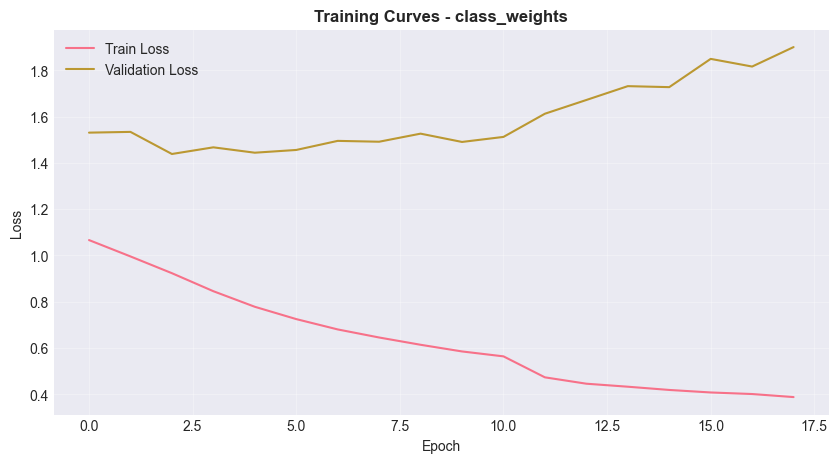


Training with strategy: focal_loss
Applying SMOTE to balance training data...
Original training size: 87796 -> Balanced size: 148780
Class distribution after SMOTE:
prevailing_species
1    37195
3    37195
0    37195
2    37195
Name: count, dtype: int64
Using device: cuda
Using Focal Loss
Epoch [10/80], Train Loss: 0.1005, Val Loss: 0.1573, LR: 0.001000
Epoch [20/80], Train Loss: 0.0586, Val Loss: 0.1791, LR: 0.000500
Early stopping at epoch 22

CNN Model Results (focal_loss):
Accuracy: 0.4862
F1-Score: 0.4956

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.44      0.30      1492
           1       0.58      0.42      0.49      9299
           2       0.58      0.57      0.58      8347
           3       0.32      0.47      0.38      2812

    accuracy                           0.49     21950
   macro avg       0.43      0.48      0.44     21950
weighted avg       0.52      0.49      0.50     21950



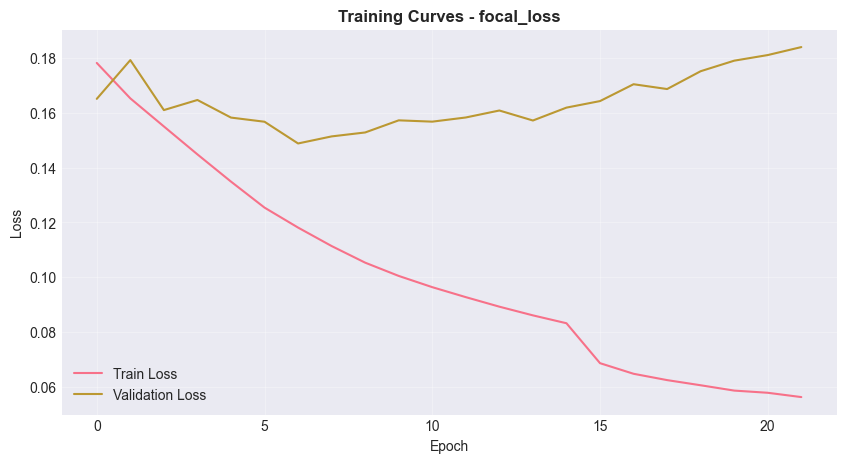


ENSEMBLE RESULTS
Ensemble Accuracy: 0.5083
Ensemble F1-Score: 0.5207

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.50      0.34      1492
           1       0.62      0.44      0.52      9299
           2       0.63      0.56      0.59      8347
           3       0.33      0.58      0.42      2812

    accuracy                           0.51     21950
   macro avg       0.46      0.52      0.47     21950
weighted avg       0.56      0.51      0.52     21950



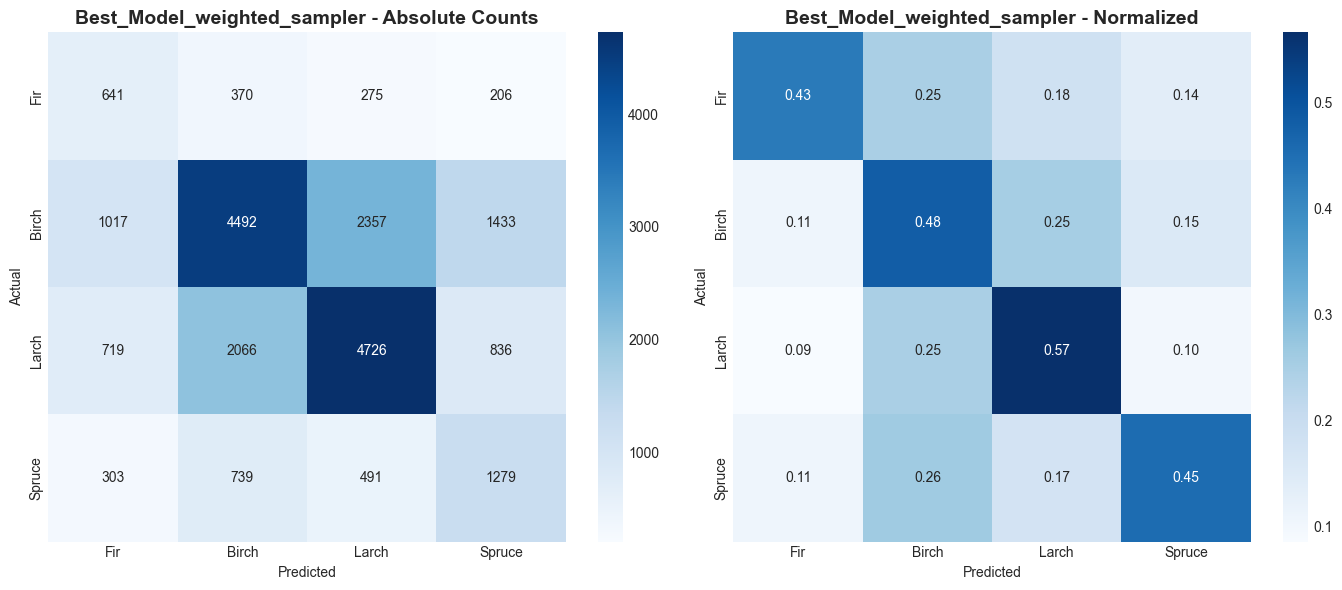

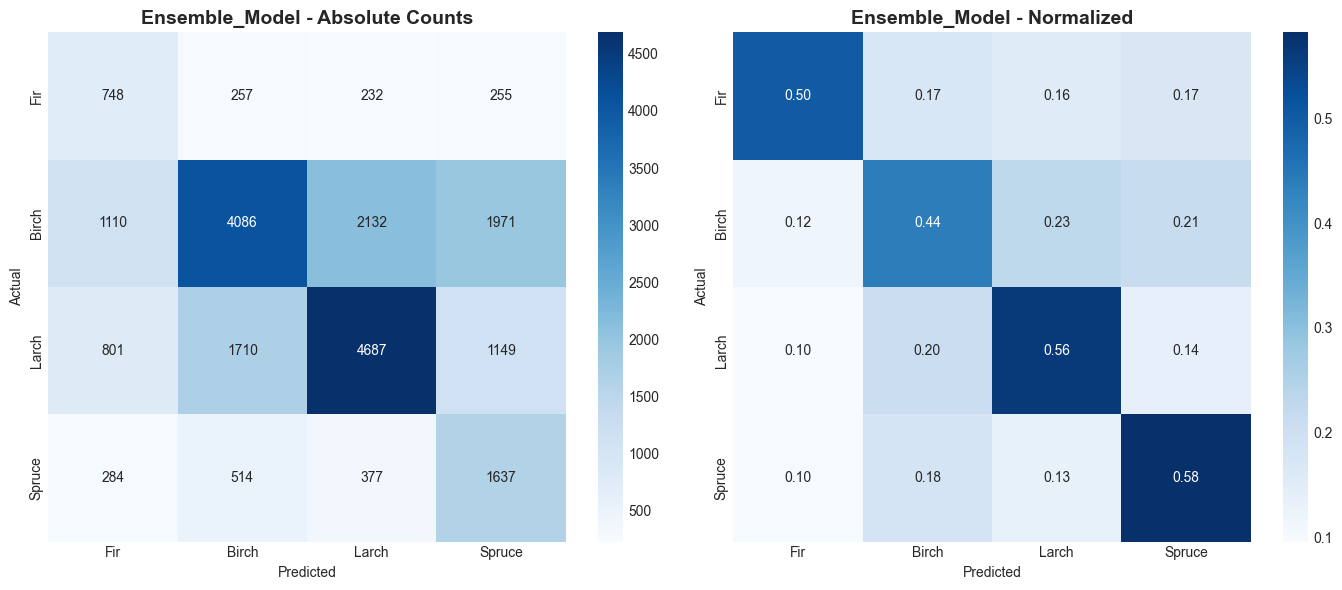


FINAL RESULTS COMPARISON

Best Individual Model (weighted_sampler):
Accuracy: 0.5074
F1-Score: 0.5171

Ensemble Model:
Accuracy: 0.5083
F1-Score: 0.5207

Best model saved as 'best_cnn_model.pth'


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. IMPROVED CNN MODEL WITH BATCH NORMALIZATION AND ADAPTIVE ARCHITECTURE
class ImprovedCNN1D(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super(ImprovedCNN1D, self).__init__()
        
        # Define activation functions FIRST
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        
        # Adaptive architecture based on input dimension
        self.conv1 = nn.Conv1d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(128)
        
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Calculate flattened size dynamically
        self.flattened_size = self._calculate_flattened_size(input_dim)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, num_classes)
        
    def _calculate_flattened_size(self, input_dim):
        """Dynamically calculate the flattened size after convolutions and pooling"""
        with torch.no_grad():
            # Create a dummy tensor to pass through conv layers
            x = torch.zeros(1, 1, input_dim)
            
            # Pass through first conv block
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Second conv block
            x = self.conv2(x)
            x = self.bn2(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Third conv block
            x = self.conv3(x)
            x = self.bn3(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Fourth conv block
            x = self.conv4(x)
            x = self.bn4(x)
            x = self.relu(x)
            x = self.pool(x)
            
            # Calculate flattened size
            return x.view(1, -1).size(1)
        
    def forward(self, x):
        x = x.unsqueeze(1)
        
        x = self.pool(self.leaky_relu(self.bn1(self.conv1(x))))
        x = self.pool(self.leaky_relu(self.bn2(self.conv2(x))))
        x = self.pool(self.leaky_relu(self.bn3(self.conv3(x))))
        x = self.pool(self.leaky_relu(self.bn4(self.conv4(x))))
        
        x = x.view(x.size(0), -1)
        
        x = self.dropout(self.leaky_relu(self.bn_fc1(self.fc1(x))))
        x = self.dropout(self.leaky_relu(self.bn_fc2(self.fc2(x))))
        x = self.fc3(x)
        
        return x

# 2. FOCAL LOSS FOR HANDLING IMBALANCE
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# 3. ADVANCED TRAINING FUNCTION WITH MULTIPLE BALANCING STRATEGIES
def train_cnn_balanced(X, y, num_classes, epochs=100, batch_size=64, 
                       strategy='weighted_sampler', learning_rate=0.001,
                       use_smote=True, early_stopping_patience=15):
    """
    Advanced training with multiple balancing strategies
    strategy: 'weighted_sampler', 'class_weights', 'focal_loss'
    """
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Apply SMOTE for training data
    if use_smote:
        print("Applying SMOTE to balance training data...")
        smote = SMOTE(random_state=42, k_neighbors=3)
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
        print(f"Original training size: {len(X_train)} -> Balanced size: {len(X_train_balanced)}")
        print(f"Class distribution after SMOTE:\n{pd.Series(y_train_balanced).value_counts()}")
    else:
        X_train_balanced, y_train_balanced = X_train, y_train
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.LongTensor(y_train_balanced.values)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_test_tensor = torch.LongTensor(y_test.values)
    
    # Create weighted sampler if strategy is 'weighted_sampler'
    if strategy == 'weighted_sampler':
        class_counts = np.bincount(y_train_tensor.numpy())
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[y_train_tensor.numpy()]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
        train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                                 batch_size=batch_size, sampler=sampler)
    else:
        train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                                 batch_size=batch_size, shuffle=True)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = ImprovedCNN1D(X.shape[1], num_classes, dropout_rate=0.3).to(device)
    
    # Class weights for loss function
    if strategy == 'class_weights':
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = torch.FloatTensor(class_weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        print(f"Class weights: {class_weights}")
    elif strategy == 'focal_loss':
        criterion = FocalLoss(alpha=0.25, gamma=2.0)
        print("Using Focal Loss")
    else:
        criterion = nn.CrossEntropyLoss()
        print("Using standard Cross Entropy Loss")
    
    # Optimizer with weight decay
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    
    # Learning rate scheduler (removed verbose parameter)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7
    )
    
    # Training loop with early stopping
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break
        
        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.6f}')
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        outputs = model(X_test_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        predicted = predicted.cpu().numpy()
        probabilities = probabilities.cpu().numpy()
    
    accuracy = accuracy_score(y_test, predicted)
    f1 = f1_score(y_test, predicted, average='weighted')
    
    print(f"\nCNN Model Results ({strategy}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, predicted))
    
    return model, accuracy, f1, train_losses, val_losses, y_test, predicted, probabilities

# 4. ENSEMBLE WITH MULTIPLE STRATEGIES
def ensemble_models(X, y, num_classes):
    """Train multiple models and combine predictions"""
    
    # Train models with different strategies
    strategies = ['weighted_sampler', 'class_weights', 'focal_loss']
    models = []
    predictions = []
    probabilities_list = []
    y_test_final = None
    
    for strategy in strategies:
        print(f"\n{'='*50}")
        print(f"Training with strategy: {strategy}")
        print('='*50)
        
        try:
            model, acc, f1, train_loss, val_loss, y_test, pred, probs = train_cnn_balanced(
                X, y, num_classes, epochs=80, batch_size=64, 
                strategy=strategy, use_smote=True
            )
            
            models.append(model)
            predictions.append(pred)
            probabilities_list.append(probs)
            y_test_final = y_test
            
            # Plot training curves for this strategy
            plt.figure(figsize=(10, 5))
            plt.plot(train_loss, label='Train Loss')
            plt.plot(val_loss, label='Validation Loss')
            plt.title(f'Training Curves - {strategy}', fontsize=12, fontweight='bold')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig(f'training_curves_{strategy}.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Strategy {strategy} failed: {e}")
            import traceback
            traceback.print_exc()
    
    # Only ensemble if we have multiple models
    if len(probabilities_list) > 1:
        # Ensemble by averaging probabilities
        avg_probabilities = np.mean(probabilities_list, axis=0)
        ensemble_pred = np.argmax(avg_probabilities, axis=1)
        
        ensemble_acc = accuracy_score(y_test_final, ensemble_pred)
        ensemble_f1 = f1_score(y_test_final, ensemble_pred, average='weighted')
        
        print(f"\n{'='*50}")
        print(f"ENSEMBLE RESULTS")
        print('='*50)
        print(f"Ensemble Accuracy: {ensemble_acc:.4f}")
        print(f"Ensemble F1-Score: {ensemble_f1:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y_test_final, ensemble_pred))
        
        return ensemble_pred, ensemble_acc, ensemble_f1, y_test_final
    else:
        print("Ensemble failed - not enough models trained")
        return None, 0, 0, None

# 5. CONFUSION MATRIX VISUALIZATION
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Absolute counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=class_names, yticklabels=class_names)
    ax1.set_title(f'{title} - Absolute Counts', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
                xticklabels=class_names, yticklabels=class_names)
    ax2.set_title(f'{title} - Normalized', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{title.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 6. RUN IMPROVED TRAINING
print("\n" + "="*80)
print("IMPROVED CNN TRAINING FOR IMBALANCED DATASET")
print("="*80)

# Check if X_all and y_species are defined
try:
    print(f"X_all shape: {X_all.shape}")
    print(f"y_species shape: {y_species.shape}")
    print(f"Unique classes in y_species: {y_species.unique()}")
    
    # Try different strategies
    strategies = ['weighted_sampler', 'class_weights', 'focal_loss']
    best_accuracy = 0
    best_results = None
    
    for strategy in strategies:
        print(f"\n{'='*60}")
        print(f"STRATEGY: {strategy.upper()}")
        print('='*60)
        
        try:
            model, acc, f1, train_loss, val_loss, y_test, pred, probs = train_cnn_balanced(
                X_all, y_species, 
                num_classes=4, 
                epochs=80, 
                batch_size=64,
                strategy=strategy,
                use_smote=True,
                learning_rate=0.001
            )
            
            if acc > best_accuracy:
                best_accuracy = acc
                best_results = (model, acc, f1, y_test, pred, probs, strategy)
                
            # Plot training curves
            plt.figure(figsize=(10, 5))
            plt.plot(train_loss, label='Train Loss')
            plt.plot(val_loss, label='Validation Loss')
            plt.title(f'Training Curves - {strategy}', fontsize=12, fontweight='bold')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig(f'training_curves_{strategy}.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Strategy {strategy} failed: {e}")
            import traceback
            traceback.print_exc()
    
    # 7. ENSEMBLE FOR BEST RESULTS
    print("\n" + "="*80)
    print("ENSEMBLE MODEL TRAINING")
    print("="*80)
    
    ensemble_pred, ensemble_acc, ensemble_f1, y_test_ens = ensemble_models(X_all, y_species, 4)
    
    # Plot confusion matrix for best model
    species_names = ['Fir', 'Birch', 'Larch', 'Spruce']
    if best_results:
        plot_confusion_matrix(best_results[3], best_results[4], species_names, 
                             f'Best_Model_{best_results[6]}')
        
    # Plot confusion matrix for ensemble if available
    if ensemble_pred is not None:
        plot_confusion_matrix(y_test_ens, ensemble_pred, species_names, 'Ensemble_Model')
    
    # 8. FINAL COMPARISON
    print("\n" + "="*80)
    print("FINAL RESULTS COMPARISON")
    print("="*80)
    
    if best_results:
        print(f"\nBest Individual Model ({best_results[6]}):")
        print(f"Accuracy: {best_results[1]:.4f}")
        print(f"F1-Score: {best_results[2]:.4f}")
    
    if ensemble_pred is not None:
        print(f"\nEnsemble Model:")
        print(f"Accuracy: {ensemble_acc:.4f}")
        print(f"F1-Score: {ensemble_f1:.4f}")
    
    # 9. SAVE BEST MODEL
    if best_results:
        torch.save(best_results[0].state_dict(), 'best_cnn_model.pth')
        print("\nBest model saved as 'best_cnn_model.pth'")
        
except NameError as e:
    print(f"Error: {e}")
    print("Please make sure X_all and y_species are defined before running this code.")


Class Imbalance Analysis - Species
Class distribution:
prevailing_species
1    46494
2    41735
3    14060
0     7457
Name: count, dtype: int64
Imbalance ratio: 0.1604

Results comparison:
               accuracy        f1
No Balancing   0.571982  0.527932
Class Weights  0.576993  0.536639
SMOTE          0.553667  0.556602

Per-class performance (SMOTE):
              precision    recall  f1-score   support

           0       0.31      0.36      0.33      1492
           1       0.60      0.59      0.59      9299
           2       0.63      0.60      0.61      8347
           3       0.36      0.40      0.38      2812

    accuracy                           0.55     21950
   macro avg       0.48      0.49      0.48     21950
weighted avg       0.56      0.55      0.56     21950


Class Imbalance Analysis - Age
Class distribution:
age
2    66826
0    17305
3    16387
1     9228
Name: count, dtype: int64
Imbalance ratio: 0.1381

Results comparison:
               accuracy        f1
No

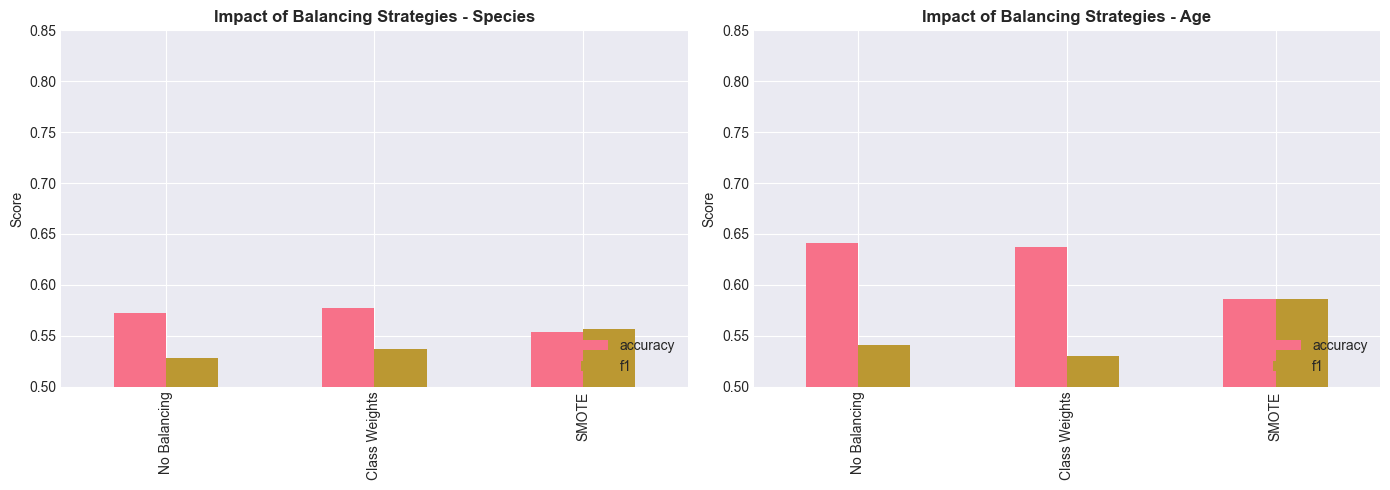

In [8]:
# 6. CLASS IMBALANCE ANALYSIS

def analyze_class_imbalance_impact(X, y, target_name):
    """Analyze the impact of class imbalance on model performance"""
    
    # Original class distribution
    class_counts = y.value_counts()
    print(f"\n{'='*50}")
    print(f"Class Imbalance Analysis - {target_name}")
    print(f"{'='*50}")
    print(f"Class distribution:\n{class_counts}")
    print(f"Imbalance ratio: {class_counts.min()/class_counts.max():.4f}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Train models with different strategies
    results = {}
    
    # Strategy 1: No balancing
    rf_no_balance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_no_balance.fit(X_train, y_train)
    y_pred_no_balance = rf_no_balance.predict(X_test)
    results['No Balancing'] = {
        'accuracy': accuracy_score(y_test, y_pred_no_balance),
        'f1': f1_score(y_test, y_pred_no_balance, average='weighted')
    }
    
    # Strategy 2: Class weights
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    weight_dict = dict(zip(np.unique(y_train), class_weights))
    rf_weights = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=weight_dict, n_jobs=-1)
    rf_weights.fit(X_train, y_train)
    y_pred_weights = rf_weights.predict(X_test)
    results['Class Weights'] = {
        'accuracy': accuracy_score(y_test, y_pred_weights),
        'f1': f1_score(y_test, y_pred_weights, average='weighted')
    }
    
    # Strategy 3: SMOTE oversampling
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = rf_smote.predict(X_test)
    results['SMOTE'] = {
        'accuracy': accuracy_score(y_test, y_pred_smote),
        'f1': f1_score(y_test, y_pred_smote, average='weighted')
    }
    
    # Display results
    results_df = pd.DataFrame(results).T
    print(f"\nResults comparison:")
    print(results_df)
    
    # Per-class performance for best model
    print(f"\nPer-class performance (SMOTE):")
    print(classification_report(y_test, y_pred_smote))
    
    return results_df, y_pred_smote

# Analyze imbalance for species
species_imbalance_results, species_smote_pred = analyze_class_imbalance_impact(X_all, y_species, 'Species')

# Analyze imbalance for age
age_imbalance_results, age_smote_pred = analyze_class_imbalance_impact(X_all, y_age, 'Age')

# Visualize imbalance impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

species_imbalance_results.plot(kind='bar', ax=ax1)
ax1.set_title('Impact of Balancing Strategies - Species', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_ylim(0.5, 0.85)
ax1.legend(loc='lower right')

age_imbalance_results.plot(kind='bar', ax=ax2)
ax2.set_title('Impact of Balancing Strategies - Age', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim(0.5, 0.85)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('class_imbalance_impact.png', dpi=300, bbox_inches='tight')
plt.show()

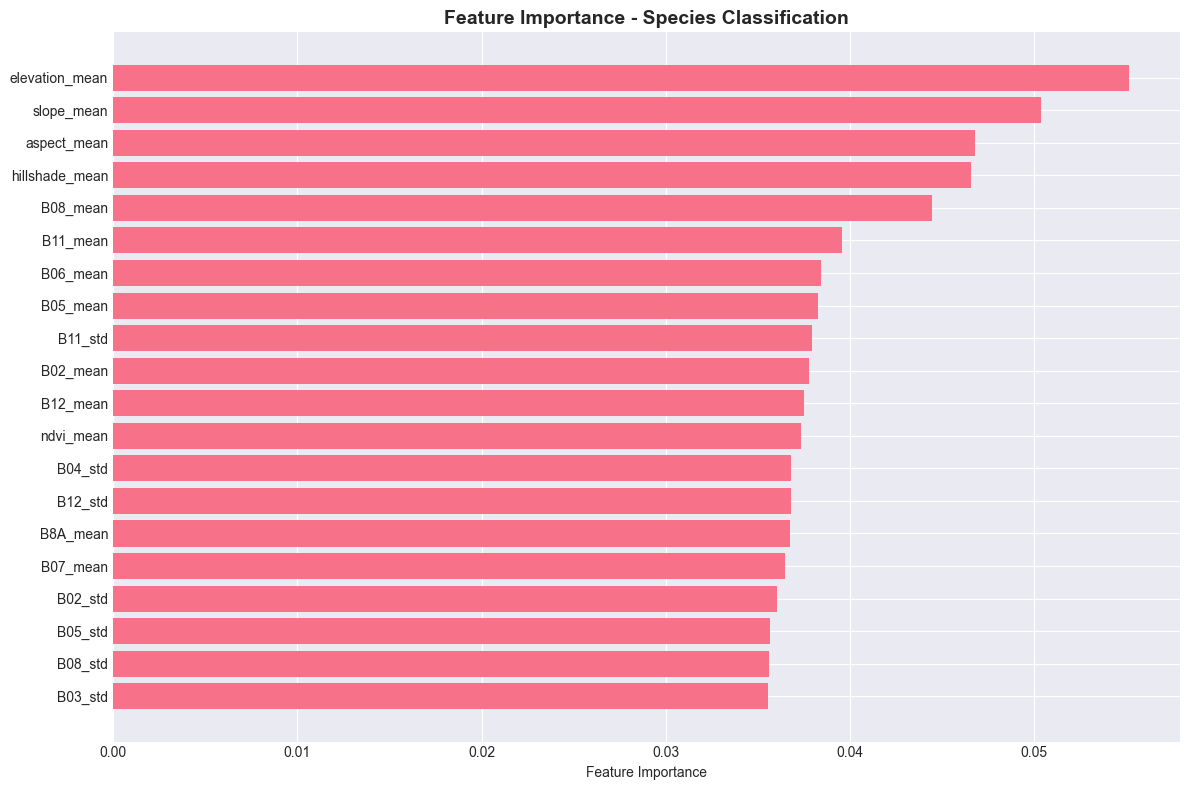


Top 10 Most Important Features:
 1. elevation_mean      : 0.0552
 2. slope_mean          : 0.0504
 3. aspect_mean         : 0.0468
 4. hillshade_mean      : 0.0466
 5. B08_mean            : 0.0445
 6. B11_mean            : 0.0396
 7. B06_mean            : 0.0384
 8. B05_mean            : 0.0383
 9. B11_std             : 0.0380
10. B02_mean            : 0.0378


In [9]:
# 7. FEATURE IMPORTANCE ANALYSIS

def analyze_feature_importance(model, X, feature_names, target_name):
    """Analyze and visualize feature importance"""
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Top 20 features
    n_top = min(20, len(feature_names))
    
    plt.figure(figsize=(12, 8))
    plt.title(f'Feature Importance - {target_name}', fontsize=14, fontweight='bold')
    plt.barh(range(n_top), importances[indices[:n_top]][::-1], align='center')
    plt.yticks(range(n_top), [feature_names[i] for i in indices[:n_top]][::-1])
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.savefig(f'feature_importance_{target_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return dict(zip(feature_names, importances))

# Train model for feature importance
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_all, y_species)

# Analyze feature importance
feature_importance_dict = analyze_feature_importance(
    rf_importance, X_all, X_all.columns.tolist(), 'Species Classification'
)

# Top 10 features
top_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Most Important Features:")
for i, (feature, importance) in enumerate(top_features, 1):
    print(f"{i:2d}. {feature:20s}: {importance:.4f}")


Performing SHAP analysis for Species...


<Figure size 1200x800 with 0 Axes>

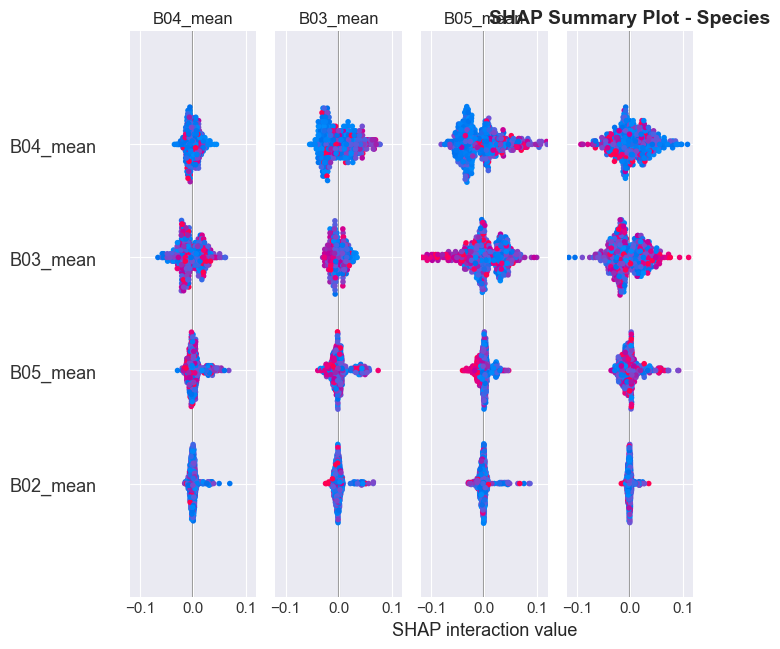

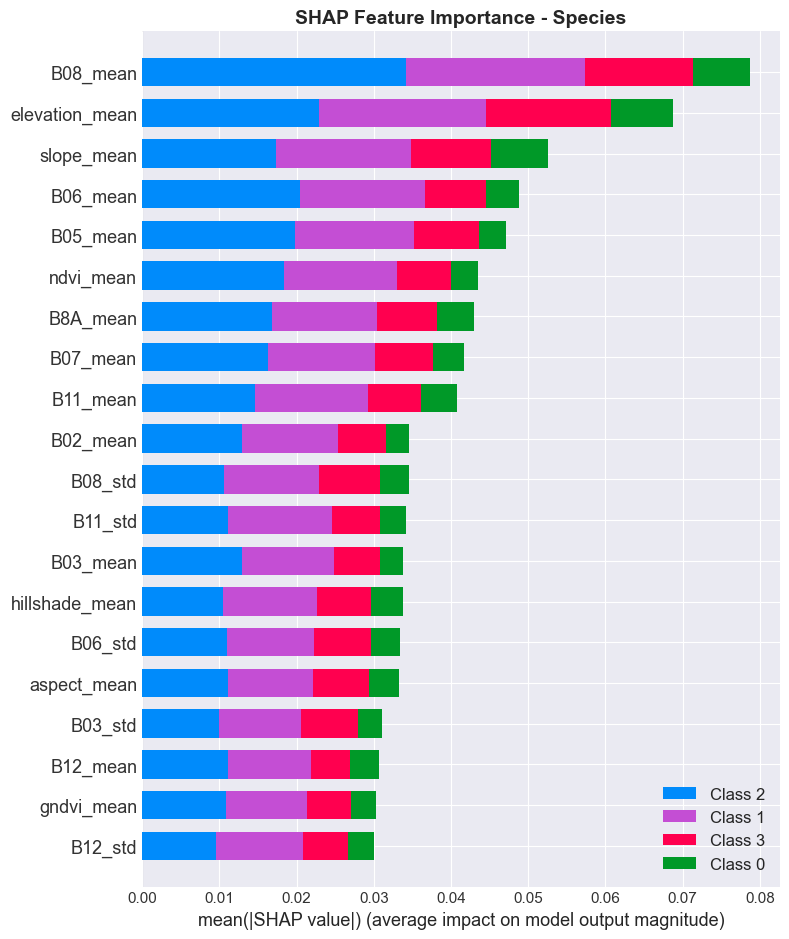

In [10]:
# 8. SHAP ANALYSIS FOR MODEL INTERPRETABILITY

def perform_shap_analysis(model, X, feature_names, target_name):
    """Perform SHAP analysis for model interpretability"""
    
    print(f"\nPerforming SHAP analysis for {target_name}...")
    
    # Use a subset for SHAP (to speed up computation)
    X_subset = X.sample(n=min(500, len(X)), random_state=42)
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_subset)
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_subset, feature_names=feature_names, show=False)
    plt.title(f'SHAP Summary Plot - {target_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_summary_{target_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Bar plot of mean absolute SHAP values
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_subset, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {target_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_bar_{target_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return explainer, shap_values

# Perform SHAP analysis for species model
try:
    shap_explainer, shap_vals = perform_shap_analysis(rf_importance, X_all, X_all.columns.tolist(), 'Species')
except Exception as e:
    print(f"SHAP analysis failed: {e}")
    print("This might be due to memory constraints or shap version issues")